# JEPA-Based Predictive Planning with MPC — Plan G
### Latent World Model + CEM Controller for CityLearn Microgrid Optimization

---

**System objective:** Learn a latent representation of microgrid dynamics using a
JEPA-style world model, then use Model Predictive Control (MPC) with the
Cross-Entropy Method (CEM) to select actions that minimize electricity cost,
peak demand, and carbon emissions.

**Architecture pipeline:**
```
State Window (24h) → Transformer Encoder → Latent z_t
                                                ↓
                               Dynamics Model: f(z_t, a_t) → z_{t+1}
                                                ↓
                                    CEM MPC Planner → Optimal Action
```

**Dataset:** CityLearn Challenge 2022 Phase All — 2.9M pre-collected transitions
stored as a flat pickle file with columns: `state`, `action`, `next_state`, `episode_id`.

---


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -q "/content/drive/MyDrive/Datasets/transitions_all_buildings.pkl.zip" -d "/content"

## Cell 1 — Install Dependencies & Imports

Install any missing packages and import everything the project needs.

In [3]:
# CityLearn is needed for the MPC evaluation loop in Stage 5.
# All other packages are standard Colab residents.
!pip install citylearn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 75.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.5/398.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.5/925.5 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.8/61.8 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 13.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This

In [ ]:
import subprocess, sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "numpy==1.26.4",
    "pandas==2.2.2",
    "citylearn"
])

# Now restart the runtime
import os
os.kill(os.getpid(), 9)

In [1]:
# ── Install (safe to re-run) ─────────────────────────────────────────────────

# ── Standard library ─────────────────────────────────────────────────────────
import os
import pickle
import random
import time
from copy import deepcopy
from pathlib import Path

# ── Numerical & data ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tqdm.notebook import tqdm

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Running on CPU — training will be slower but fully functional.")


Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## Cell 2 — Global Hyperparameters

All tunable values live here. Nothing is hardcoded elsewhere in the notebook.
Change values in this cell only.


In [2]:
# ── Data ──────────────────────────────────────────────────────────────────────
PICKLE_PATH     = "/content/transitions_all_buildings.pkl"   # ← set your actual pickle path here
WINDOW_LEN      = 24                  # hours of history fed to the encoder
ROLLOUT_STEPS   = 5                   # multi-step prediction depth during training
EPISODE_LEN     = 8758                # timesteps per episode (1 year hourly)

# ── Architecture ──────────────────────────────────────────────────────────────
LATENT_DIM      = 64                  # z dimension
HIDDEN_DIM      = 128                 # transformer hidden size
N_HEADS         = 4                   # attention heads
N_LAYERS        = 4                   # transformer encoder layers
DROPOUT         = 0.1

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE      = 512
LEARNING_RATE   = 3e-4
WEIGHT_DECAY    = 1e-5
N_EPOCHS        = 15                  # increase for better convergence
GRAD_CLIP       = 1.0

# ── VICReg loss weights ───────────────────────────────────────────────────────
LAMBDA_INV      = 1.0                 # prediction (invariance) loss weight
LAMBDA_VAR      = 25.0                # variance regularization weight
LAMBDA_COV      = 1.0                 # covariance regularization weight

# ── Masking probabilities ─────────────────────────────────────────────────────
# Applied per-feature at training time to force causal inference
MASK_PROB_INTERNAL   = 0.40           # battery SOC, thermal storage, temperatures
MASK_PROB_GRID       = 0.30           # electricity price, carbon, demand signals
MASK_PROB_EXOGENOUS  = 0.10           # weather, solar radiation (observe more often)

# ── MPC / CEM ─────────────────────────────────────────────────────────────────
PLAN_HORIZON    = 12                  # hours ahead the planner optimises
CEM_SAMPLES     = 256                 # candidate action sequences per iteration
CEM_ITERATIONS  = 4                   # CEM refinement iterations
CEM_ELITE_FRAC  = 0.10                # top 10% kept as elite
CEM_ALPHA       = 0.1                 # smoothing: new_mu = alpha*old + (1-alpha)*elite

# ── Cost function weights ─────────────────────────────────────────────────────
COST_ALPHA      = 1.0                 # electricity cost weight
COST_BETA       = 0.5                 # peak demand weight
COST_GAMMA      = 0.3                 # carbon emissions weight

# ── Evaluation ────────────────────────────────────────────────────────────────
EVAL_EPISODES   = 2                   # number of CityLearn episodes to evaluate

print("Hyperparameters set.")
print(f"  Window length     : {WINDOW_LEN}")
print(f"  Latent dim        : {LATENT_DIM}")
print(f"  Transformer layers: {N_LAYERS}")
print(f"  Rollout steps     : {ROLLOUT_STEPS}")
print(f"  Planning horizon  : {PLAN_HORIZON}")


Hyperparameters set.
  Window length     : 24
  Latent dim        : 64
  Transformer layers: 4
  Rollout steps     : 5
  Planning horizon  : 12


## Cell 3 — Load & Inspect the Transition Dataset

Load the pickle, introspect dimensions, confirm episode structure, and
run basic sanity checks before any model code runs.


In [3]:
import gc; gc.collect()

107

In [4]:
import gc

# ── Load and immediately convert to flat arrays ───────────────────────────────
# The DataFrame with object-dtype columns (each cell = a numpy array)
# uses 3–5× more RAM than the raw data. We extract flat arrays and
# drop df instantly.

print(f"Loading: {PICKLE_PATH}")
with open(PICKLE_PATH, "rb") as f:
    df = pickle.load(f)

print(f"DataFrame shape : {df.shape}")

# Grab episode_id column before converting (it's already integers — cheap)
episode_ids_raw = df["episode_id"].values.copy()   # (N,) int

# Extract flat arrays one at a time, deleting each df column immediately after
# to avoid holding both the object column and the float array simultaneously
print("Extracting states...")
states_arr = np.stack(df["state"].values).astype(np.float32)
df.drop(columns=["state"], inplace=True)
gc.collect()

print("Extracting actions...")
actions_arr = np.stack(df["action"].values).astype(np.float32)
df.drop(columns=["action"], inplace=True)
gc.collect()

print("Extracting next_states...")
next_states_arr = np.stack(df["next_state"].values).astype(np.float32)
df.drop(columns=["next_state"], inplace=True)
gc.collect()

# Drop the DataFrame entirely — only flat arrays remain
del df
gc.collect()

print("DataFrame released.")
print(f"  states      : {states_arr.shape}  {states_arr.nbytes/1e9:.2f} GB")
print(f"  actions     : {actions_arr.shape}  {actions_arr.nbytes/1e9:.3f} GB")
print(f"  next_states : {next_states_arr.shape}  {next_states_arr.nbytes/1e9:.2f} GB")

# ── Introspect dimensions ─────────────────────────────────────────────────────
STATE_DIM  = states_arr.shape[1]
ACTION_DIM = actions_arr.shape[1]
N_TOTAL    = states_arr.shape[0]
print(f"\nState dim  (S): {STATE_DIM}")
print(f"Action dim (A): {ACTION_DIM}")
print(f"Total rows     : {N_TOTAL:,}")

# ── Detect building structure from actual episode row counts ──────────────────
ep_row_counts = np.bincount(episode_ids_raw.astype(np.int32))
print(f"Rows per episode: min={ep_row_counts.min():,}  max={ep_row_counts.max():,}")
print(f"Unique episode lengths: {np.unique(ep_row_counts)}")

# Use the most common episode length to detect N_BUILDINGS
from collections import Counter
most_common_ep_len = Counter(ep_row_counts.tolist()).most_common(1)[0][0]
N_BUILDINGS = most_common_ep_len // EPISODE_LEN
print(f"Most common episode length : {most_common_ep_len:,}")
print(f"Buildings detected         : {N_BUILDINGS}")

# ── Assign step_within_seq and building_ep_id per episode ────────────────────
step_within_seq = np.full(N_TOTAL, -1, dtype=np.int32)
building_ep_id  = np.full(N_TOTAL, -1, dtype=np.int32)

seq_counter = 0
cursor = 0
# Define N_SIM_EPISODES before its usage
N_SIM_EPISODES = len(ep_row_counts)
for ep in range(N_SIM_EPISODES):
    ep_len    = int(ep_row_counts[ep])
    n_b       = ep_len // EPISODE_LEN
    remainder = ep_len %  EPISODE_LEN

    for b in range(n_b):
        start = cursor + b * EPISODE_LEN
        end   = start  + EPISODE_LEN
        step_within_seq[start:end] = np.arange(EPISODE_LEN, dtype=np.int32)
        building_ep_id[start:end]  = seq_counter
        seq_counter += 1

    if remainder != 0:
        # Mark leftover rows invalid — excluded automatically by valid index guard
        leftover = cursor + n_b * EPISODE_LEN
        print(f"  Episode {ep}: {remainder} leftover rows marked invalid")

    cursor += ep_len

n_sequences = seq_counter
print(f"\nTotal sequences assigned : {n_sequences}")

# ── Verify only rows assigned to complete sequences ───────────────────────────
assigned = building_ep_id >= 0
counts   = np.bincount(building_ep_id[assigned])
assert (counts == EPISODE_LEN).all(), \
    f"Unequal sequence lengths: min={counts.min()} max={counts.max()}"
print(f"All {n_sequences} sequences exactly {EPISODE_LEN} steps: ✓")
del counts
gc.collect()

Loading: /content/transitions_all_buildings.pkl
DataFrame shape : (2978060, 4)
Extracting states...
Extracting actions...
Extracting next_states...
DataFrame released.
  states      : (2978060, 28)  0.33 GB
  actions     : (2978060, 1)  0.012 GB
  next_states : (2978060, 28)  0.33 GB

State dim  (S): 28
Action dim (A): 1
Total rows     : 2,978,060
Rows per episode: min=148,903  max=148,903
Unique episode lengths: [148903]
Most common episode length : 148,903
Buildings detected         : 17
  Episode 0: 17 leftover rows marked invalid
  Episode 1: 17 leftover rows marked invalid
  Episode 2: 17 leftover rows marked invalid
  Episode 3: 17 leftover rows marked invalid
  Episode 4: 17 leftover rows marked invalid
  Episode 5: 17 leftover rows marked invalid
  Episode 6: 17 leftover rows marked invalid
  Episode 7: 17 leftover rows marked invalid
  Episode 8: 17 leftover rows marked invalid
  Episode 9: 17 leftover rows marked invalid
  Episode 10: 17 leftover rows marked invalid
  Episode

0

## Cell 4 — Visualize Time-Series Structure

Plot key state features over time to confirm seasonality, daily cycles,
and disturbance patterns that the encoder will need to capture.


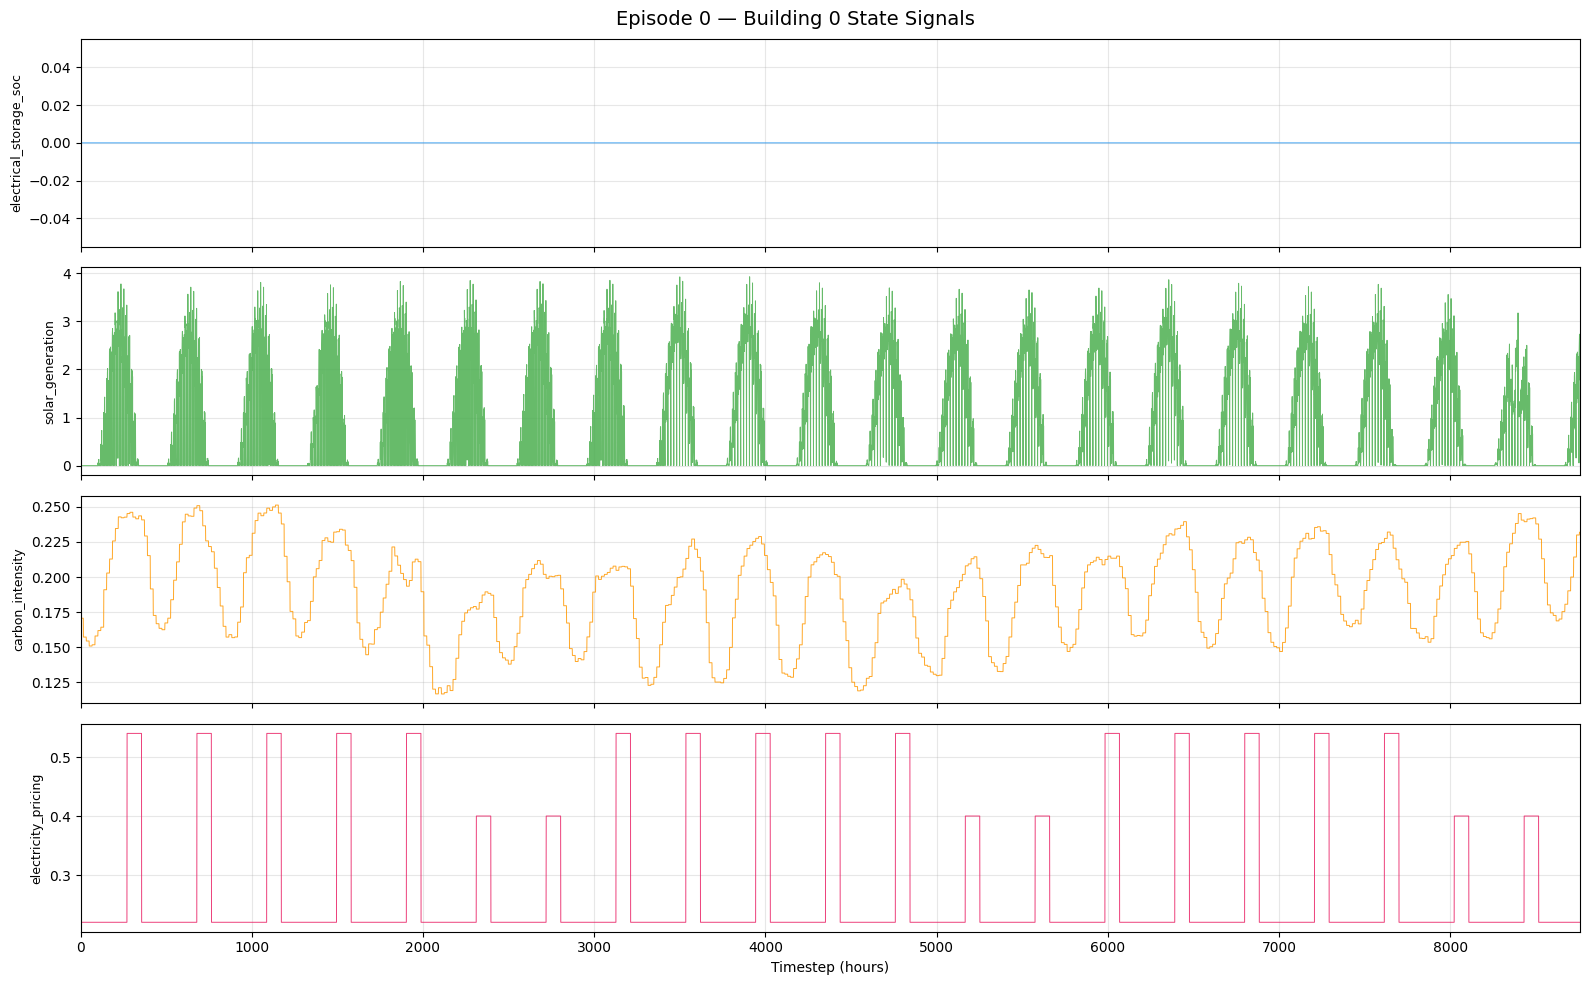

Time-series plot saved.


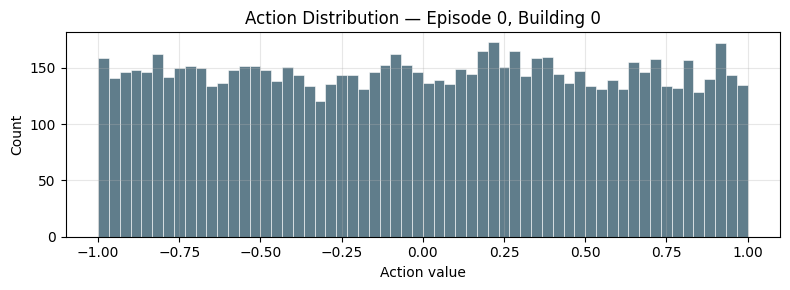

42

In [5]:
# ── Visualize using pre-extracted flat arrays ─────────────────────────────────
# df no longer exists — use states_arr, actions_arr, episode_ids_raw directly.
# Episode 0 occupies the first rows_per_sim_episode rows.

ep0_mask    = episode_ids_raw == 0
ep0_states  = states_arr[ep0_mask]    # (148903, 28)
ep0_actions = actions_arr[ep0_mask]   # (148903, 1)

# Use only the first building's 8758 timesteps for a clean single-sequence plot
ep0_states  = ep0_states[:EPISODE_LEN]    # (8758, 28)
ep0_actions = ep0_actions[:EPISODE_LEN]   # (8758, 1)

FEATURE_NAMES = [
    'month', 'day_type', 'hour',
    'outdoor_dry_bulb_temperature', 'outdoor_dry_bulb_temperature_p1',
    'outdoor_dry_bulb_temperature_p2', 'outdoor_dry_bulb_temperature_p3',
    'outdoor_relative_humidity', 'outdoor_relative_humidity_p1',
    'outdoor_relative_humidity_p2', 'outdoor_relative_humidity_p3',
    'diffuse_solar_irradiance', 'diffuse_solar_irradiance_p1',
    'diffuse_solar_irradiance_p2', 'diffuse_solar_irradiance_p3',
    'direct_solar_irradiance', 'direct_solar_irradiance_p1',
    'direct_solar_irradiance_p2', 'direct_solar_irradiance_p3',
    'carbon_intensity', 'non_shiftable_load', 'solar_generation',
    'electrical_storage_soc', 'net_electricity_consumption',
    'electricity_pricing', 'electricity_pricing_p1',
    'electricity_pricing_p2', 'electricity_pricing_p3',
]

# Plot 4 most informative features
PLOT_INDICES = [22, 21, 19, 24]   # SOC, solar_generation, carbon_intensity, price

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
fig.suptitle("Episode 0 — Building 0 State Signals", fontsize=14)

colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]
for ax, idx, color in zip(axes, PLOT_INDICES, colors):
    ax.plot(ep0_states[:, idx], color=color, linewidth=0.7, alpha=0.85)
    ax.set_ylabel(FEATURE_NAMES[idx], fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, EPISODE_LEN)

axes[-1].set_xlabel("Timestep (hours)", fontsize=10)
plt.tight_layout()
plt.savefig("timeseries_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Time-series plot saved.")

# ── Action distribution ───────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.hist(ep0_actions.flatten(), bins=60, color="#607D8B", edgecolor="white", linewidth=0.4)
ax.set_title("Action Distribution — Episode 0, Building 0")
ax.set_xlabel("Action value")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("action_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

del ep0_states, ep0_actions, ep0_mask
gc.collect()

## Cell 5 — Build Valid Training Index Pool

Compute `step_within_episode` for every row, then filter to indices where:
1. A full 24-step input window fits (no cross-episode contamination at the start).
2. A full K-step rollout target fits (no cross-episode contamination at the end).

These valid indices form the **only** pool sampled during training.


In [6]:
# ── Valid index mask ──────────────────────────────────────────────────────────
# step_within_seq and building_ep_id are numpy arrays built in Cell 3.
# Window guard : t >= W-1 (full 24-step window fits without crossing boundary)
# Rollout guard: t <= EPISODE_LEN - K - 1 (full K-step rollout fits)
# Rows marked invalid in Cell 3 (leftover rows) have step_within_seq == -1
# and are automatically excluded by the window guard.

window_guard  = step_within_seq >= (WINDOW_LEN - 1)
rollout_guard = step_within_seq <= (EPISODE_LEN - ROLLOUT_STEPS - 1)
VALID_INDICES = np.where(window_guard & rollout_guard)[0].tolist()

print(f"Total transitions  : {N_TOTAL:,}")
print(f"Valid for training  : {len(VALID_INDICES):,}  ({100*len(VALID_INDICES)/N_TOTAL:.2f}%)")
print(f"Excluded (boundary): {N_TOTAL - len(VALID_INDICES):,}")

Total transitions  : 2,978,060
Valid for training  : 2,968,200  (99.67%)
Excluded (boundary): 9,860


## Cell 6 — Define Feature Masking Groups

Features are grouped by their physical category, each with a different
masking probability during training:

| Category | Mask prob | Reason |
|---|---|---|
| Internal states (SOC, temperature) | 40% | Force model to learn energy conservation dynamics |
| Grid signals (price, carbon, demand) | 30% | Learn grid influence on optimal behavior |
| Exogenous weather | 10% | External disturbances — observe more often |
| Unassigned features | 0% | Fallback: never mask by default |

**You must set the index ranges below to match your actual dataset.**
CityLearn 2022 state vectors follow a documented ordering — consult your
environment's `observation_names` to confirm.


In [7]:
# ── Feature group index assignment ────────────────────────────────────────────
# IMPORTANT: adjust these index ranges to match your actual state vector ordering.
# Run: env.observation_names  in a CityLearn session to see the ordering.
#
# The defaults below assume a 28-feature state with a typical CityLearn ordering.
# Even if the ranges are slightly off, the model will still train — masking
# is a regularizer, not a hard requirement.

INTERNAL_INDICES  = [22]                        # electrical_storage_soc
GRID_INDICES      = [19, 20, 23, 24, 25, 26, 27] # carbon_intensity, non_shiftable_load,
                                                 # net_electricity_consumption, electricity_pricing x4
EXOGENOUS_INDICES = [3, 4, 5, 6,                # outdoor_dry_bulb_temperature x4
                     7, 8, 9, 10,               # outdoor_relative_humidity x4
                     11, 12, 13, 14,            # diffuse_solar_irradiance x4
                     15, 16, 17, 18,            # direct_solar_irradiance x4
                     21]                        # solar_generation
# Indices 0,1,2 (month, day_type, hour) — no masking. These are time encodings
# the model must always observe to anchor temporal position.

def build_mask_probs(state_dim):
    """Return per-feature masking probability vector of shape (state_dim,)."""
    probs = np.zeros(state_dim, dtype=np.float32)
    for idx in INTERNAL_INDICES:
        if idx < state_dim:
            probs[idx] = MASK_PROB_INTERNAL
    for idx in GRID_INDICES:
        if idx < state_dim:
            probs[idx] = MASK_PROB_GRID
    for idx in EXOGENOUS_INDICES:
        if idx < state_dim:
            probs[idx] = MASK_PROB_EXOGENOUS
    return probs

MASK_PROBS = build_mask_probs(STATE_DIM)   # (S,)  — used in the Dataset class

print("Feature masking probability vector:")
for i, p in enumerate(MASK_PROBS):
    if p > 0:
        print(f"  feature {i:2d}: {p:.2f}")
print(f"  (remaining {int((MASK_PROBS == 0).sum())} features): 0.00")


Feature masking probability vector:
  feature  3: 0.10
  feature  4: 0.10
  feature  5: 0.10
  feature  6: 0.10
  feature  7: 0.10
  feature  8: 0.10
  feature  9: 0.10
  feature 10: 0.10
  feature 11: 0.10
  feature 12: 0.10
  feature 13: 0.10
  feature 14: 0.10
  feature 15: 0.10
  feature 16: 0.10
  feature 17: 0.10
  feature 18: 0.10
  feature 19: 0.30
  feature 20: 0.30
  feature 21: 0.10
  feature 22: 0.40
  feature 23: 0.30
  feature 24: 0.30
  feature 25: 0.30
  feature 26: 0.30
  feature 27: 0.30
  (remaining 3 features): 0.00


## Cell 7 — PyTorch Dataset & DataLoader

`JEPADataset` samples a valid anchor index, constructs the 24-step input window
lazily (no pre-allocation), fetches K consecutive rollout targets, and applies
structured feature masking to the window.

Windows are built lazily at sample time to keep RAM usage to ~2 GB regardless
of dataset size.


In [8]:
import gc; gc.collect()

0

In [9]:
class RevIN(nn.Module):
    """
    Reversible Instance Normalization (Kim et al., 2022).
    Normalizes each sample independently across the time axis,
    per feature. Inverse transform restores original scale.

    Input:  (B, T, C)
    Output: (B, T, C)  normalized, with stored mean/std for denorm.
    """
    def __init__(self, num_features: int, eps: float = 1e-5):
        super().__init__()
        self.num_features = num_features
        self.eps = eps
        # Learnable affine parameters (one per feature)
        self.affine_weight = nn.Parameter(torch.ones(num_features))
        self.affine_bias   = nn.Parameter(torch.zeros(num_features))

    def forward(self, x: torch.Tensor, mode: str = "norm") -> torch.Tensor:
        """
        mode='norm'  : normalize and store stats
        mode='denorm': reverse normalization using stored stats
        """
        if mode == "norm":
            # mean/std over time axis, per (sample, feature)
            self._mean = x.mean(dim=1, keepdim=True)          # (B, 1, C)
            self._std  = x.std(dim=1, keepdim=True) + self.eps # (B, 1, C)
            x = (x - self._mean) / self._std
            x = x * self.affine_weight + self.affine_bias
        elif mode == "denorm":
            x = (x - self.affine_bias) / (self.affine_weight + self.eps)
            x = x * self._std + self._mean
        return x


class JEPADataset(Dataset):
    """
    Lazy-window dataset for JEPA world-model training.
    Reads directly from module-level numpy arrays:
        states_arr, actions_arr, next_states_arr
    No DataFrame involved — zero additional RAM cost.

    valid_indices only contains rows where step_within_seq >= W-1
    and step_within_seq <= EPISODE_LEN - K - 1, guaranteeing no
    window or rollout crosses a building sequence boundary.
    """
    def __init__(self, valid_indices: list,
                 state_dim: int, action_dim: int,
                 window_len: int, rollout_steps: int,
                 mask_probs: np.ndarray):
        self.valid_indices = valid_indices
        self.S  = state_dim
        self.A  = action_dim
        self.W  = window_len
        self.K  = rollout_steps
        self.mask_probs = mask_probs  # (S,) float32

    def __len__(self):
        return len(self.valid_indices)

    def _get_window(self, anchor_idx: int) -> np.ndarray:
        """Slice rows [anchor-W+1 .. anchor] to form a (W, S) window."""
        start = anchor_idx - self.W + 1
        return states_arr[start : anchor_idx + 1]   # (W, S)

    def _apply_mask(self, window: np.ndarray) -> np.ndarray:
        """
        Apply structured feature masking to window (W, S).
        Each feature dimension is independently masked with its probability.
        Masked positions are set to 0.0 (the post-RevIN mean).
        """
        mask   = np.random.rand(self.S) < self.mask_probs  # (S,) bool
        masked = window.copy()
        masked[:, mask] = 0.0
        return masked

    def __getitem__(self, idx: int):
        anchor = self.valid_indices[idx]

        # ── Input window ──────────────────────────────────────────────────────
        clean_window  = self._get_window(anchor)        # (W, S)
        masked_window = self._apply_mask(clean_window)  # (W, S)

        # ── K-step rollout targets ─────────────────────────────────────────────
        actions_seq = actions_arr[anchor : anchor + self.K]  # (K, A)
        next_wins   = np.stack([
            states_arr[anchor + k + 1 - self.W + 1 : anchor + k + 2]
            for k in range(self.K)
        ])  # (K, W, S)

        return (
            torch.from_numpy(masked_window),   # (W, S)
            torch.from_numpy(clean_window),    # (W, S)
            torch.from_numpy(actions_seq),     # (K, A)
            torch.from_numpy(next_wins),       # (K, W, S)
        )


# ── Instantiate ───────────────────────────────────────────────────────────────
dataset = JEPADataset(
    valid_indices = VALID_INDICES,
    state_dim     = STATE_DIM,
    action_dim    = ACTION_DIM,
    window_len    = WINDOW_LEN,
    rollout_steps = ROLLOUT_STEPS,
    mask_probs    = MASK_PROBS,
)

# No df to delete — already gone. Just collect any lingering garbage.
gc.collect()

n_train = int(0.9 * len(dataset))
n_val   = len(dataset) - n_train
train_set, val_set = torch.utils.data.random_split(
    dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=(DEVICE.type == "cuda"),
                          drop_last=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=(DEVICE.type == "cuda"),
                          drop_last=False)

print(f"Dataset size       : {len(dataset):,}")
print(f"Train batches      : {len(train_loader):,}  ({n_train:,} samples)")
print(f"Val   batches      : {len(val_loader):,}  ({n_val:,} samples)")

# ── Shape sanity check ────────────────────────────────────────────────────────
mw, cw, acts, nws = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  masked_window  : {tuple(mw.shape)}   expected ({BATCH_SIZE}, {WINDOW_LEN}, {STATE_DIM})")
print(f"  clean_window   : {tuple(cw.shape)}")
print(f"  actions        : {tuple(acts.shape)}    expected ({BATCH_SIZE}, {ROLLOUT_STEPS}, {ACTION_DIM})")
print(f"  next_windows   : {tuple(nws.shape)}  expected ({BATCH_SIZE}, {ROLLOUT_STEPS}, {WINDOW_LEN}, {STATE_DIM})")
assert mw.shape  == (BATCH_SIZE, WINDOW_LEN, STATE_DIM)
assert acts.shape == (BATCH_SIZE, ROLLOUT_STEPS, ACTION_DIM)
assert nws.shape  == (BATCH_SIZE, ROLLOUT_STEPS, WINDOW_LEN, STATE_DIM)
print("\nAll shapes correct: ✓")

Dataset size       : 2,968,200
Train batches      : 5,217  (2,671,380 samples)
Val   batches      : 580  (296,820 samples)

Batch shapes:
  masked_window  : (512, 24, 28)   expected (512, 24, 28)
  clean_window   : (512, 24, 28)
  actions        : (512, 5, 1)    expected (512, 5, 1)
  next_windows   : (512, 5, 24, 28)  expected (512, 5, 24, 28)

All shapes correct: ✓


## Cell 8 — Temporal Transformer Encoder

The encoder maps a 24-step state window to a 64-dimensional latent vector.

Architecture:
```
(B, W, S)
  → Linear embedding         (B, W, hidden_dim)
  → Positional encoding      (B, W, hidden_dim)
  → 4× TransformerEncoder    (B, W, hidden_dim)
  → Mean pooling             (B, hidden_dim)
  → Linear projection        (B, latent_dim)
```

RevIN normalization is applied to the raw window **before** the linear
embedding, operating in the temporal dimension per feature.


In [10]:
class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding for sequences of length up to max_len.
    Adds a fixed (non-learned) position signal to the embedding.
    """
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)   # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class TemporalEncoder(nn.Module):
    """
    Temporal Transformer encoder.

    Takes a state window (possibly with RevIN applied externally) and
    produces a fixed-size latent vector z.

    Forward signature:
        x : (B, W, S)  — state window, already RevIN-normalized
    Returns:
        z : (B, D)     — latent representation
    """
    def __init__(self, state_dim: int, hidden_dim: int, latent_dim: int,
                 n_heads: int, n_layers: int, window_len: int,
                 dropout: float = 0.1):
        super().__init__()
        self.input_proj = nn.Linear(state_dim, hidden_dim)
        self.pos_enc    = PositionalEncoding(hidden_dim, max_len=window_len + 8,
                                             dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=n_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            batch_first=True,   # (B, T, D) convention throughout
            norm_first=True,    # Pre-LN: more stable training than post-LN
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers,
                                                  enable_nested_tensor=False)
        self.pool       = nn.AdaptiveAvgPool1d(1)   # mean pooling over time
        self.out_proj   = nn.Linear(hidden_dim, latent_dim)
        self.layer_norm = nn.LayerNorm(latent_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, W, S)
        x = self.input_proj(x)          # (B, W, hidden_dim)
        x = self.pos_enc(x)             # (B, W, hidden_dim)
        x = self.transformer(x)         # (B, W, hidden_dim)
        # Mean pooling: pool1d expects (B, C, L) — transpose then back
        x = self.pool(x.transpose(1, 2)).squeeze(-1)  # (B, hidden_dim)
        x = self.out_proj(x)            # (B, latent_dim)
        x = self.layer_norm(x)          # (B, latent_dim)
        return x


# ── Quick shape test ─────────────────────────────────────────────────────────
_enc = TemporalEncoder(STATE_DIM, HIDDEN_DIM, LATENT_DIM,
                       N_HEADS, N_LAYERS, WINDOW_LEN, DROPOUT)
_x   = torch.randn(4, WINDOW_LEN, STATE_DIM)
_z   = _enc(_x)
assert _z.shape == (4, LATENT_DIM), f"Encoder output shape wrong: {_z.shape}"
print(f"TemporalEncoder output shape: {tuple(_z.shape)}  ✓")
print(f"Parameters: {sum(p.numel() for p in _enc.parameters()):,}")
del _enc, _x, _z


TemporalEncoder output shape: (4, 64)  ✓
Parameters: 805,184


## Cell 9 — Latent Dynamics Model

The dynamics model predicts the next latent state given the current latent
state and the action taken:

```
z_{t+1} = f(z_t, a_t)
```

Architecture: MLP with residual connection.
```
concat(z_t, a_t)  →  Linear → LayerNorm → SiLU
                  →  Linear → LayerNorm → SiLU
                  →  Linear → LayerNorm → SiLU
                  →  Linear → + residual(z_t)
```

The residual connection (from z_t, projected to latent_dim) biases the
network toward learning **delta dynamics** rather than reconstructing z_t
from scratch at every step — this significantly improves multi-step
rollout stability.


In [11]:
class DynamicsModel(nn.Module):
    """
    MLP dynamics model with residual connection.
    Predicts next latent z_{t+1} from (z_t, a_t).

    Forward:
        z : (B, D)  — current latent
        a : (B, A)  — action
    Returns:
        z_next : (B, D)  — predicted next latent
    """
    def __init__(self, latent_dim: int, action_dim: int, hidden_dim: int = 256):
        super().__init__()
        inp = latent_dim + action_dim
        self.net = nn.Sequential(
            nn.Linear(inp, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, latent_dim),
        )
        # Residual projection: maps z_t from latent_dim to latent_dim (identity
        # if dims match, but explicit to allow dim changes later)
        self.residual_proj = nn.Linear(latent_dim, latent_dim, bias=False)
        self.out_norm      = nn.LayerNorm(latent_dim)

    def forward(self, z: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
        # z: (B, D), a: (B, A)
        x      = torch.cat([z, a], dim=-1)     # (B, D+A)
        delta  = self.net(x)                   # (B, D)
        z_next = self.out_norm(delta + self.residual_proj(z))
        return z_next


# ── Quick shape test ─────────────────────────────────────────────────────────
_dyn = DynamicsModel(LATENT_DIM, ACTION_DIM)
_z   = torch.randn(4, LATENT_DIM)
_a   = torch.randn(4, ACTION_DIM)
_zn  = _dyn(_z, _a)
assert _zn.shape == (4, LATENT_DIM), f"Dynamics output shape wrong: {_zn.shape}"
print(f"DynamicsModel output shape: {tuple(_zn.shape)}  ✓")
print(f"Parameters: {sum(p.numel() for p in _dyn.parameters()):,}")
del _dyn, _z, _a, _zn


DynamicsModel output shape: (4, 64)  ✓
Parameters: 170,688


## Cell 10 — Full JEPA World Model

Wraps encoder + RevIN + dynamics model into a single `nn.Module` with
a clean forward API for both training and inference.

Two forward modes:
- `encode(window)` — encode a window to latent z (used in MPC)
- `forward(masked_window, actions, target_windows)` — full training forward pass


In [12]:
class JEPAWorldModel(nn.Module):
    """
    Complete JEPA world model.

    Components:
        revin    : RevIN normalization (per-sample, per-feature, over time axis)
        encoder  : TemporalEncoder — window → latent z
        dynamics : DynamicsModel   — (z, a) → z_next

    Training forward pass:
        1. RevIN-normalize masked_window and each target window
        2. Encode masked_window → z_0
        3. Encode each target window (clean) → z_targets[k]  (stop gradient)
        4. Unroll dynamics K steps using z_0 and actions → z_preds[k]
        5. Return predicted and target latent sequences for loss computation

    Inference:
        encode(window) → z  (used by MPC planner)
        step(z, a)     → z_next
    """
    def __init__(self, state_dim, action_dim, hidden_dim, latent_dim,
                 n_heads, n_layers, window_len, dropout):
        super().__init__()
        self.revin    = RevIN(state_dim)
        self.encoder  = TemporalEncoder(state_dim, hidden_dim, latent_dim,
                                        n_heads, n_layers, window_len, dropout)
        self.dynamics = DynamicsModel(latent_dim, action_dim, hidden_dim * 2)

    def encode(self, window: torch.Tensor) -> torch.Tensor:
        """
        window : (B, W, S)  — raw (unnormalized) state window
        returns: (B, D)     — latent vector
        """
        x = self.revin(window, mode="norm")
        return self.encoder(x)

    def step(self, z: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
        """Single dynamics step. z: (B,D), a: (B,A) → (B,D)."""
        return self.dynamics(z, a)

    def forward(self, masked_window: torch.Tensor,
                actions: torch.Tensor,
                target_windows: torch.Tensor):
        """
        masked_window  : (B, W, S)
        actions        : (B, K, A)
        target_windows : (B, K, W, S)

        Returns:
            z_preds   : (B, K, D)  — dynamics rollout predictions
            z_targets : (B, K, D)  — encoder targets (stop-gradient)
        """
        B, K, W, S = target_windows.shape

        # ── Encode anchor (masked) ─────────────────────────────────────────────
        z_t = self.encode(masked_window)  # (B, D)

        # ── Encode targets (no gradient through targets) ───────────────────────
        # Reshape to (B*K, W, S) for batch encoding, then reshape back
        tgt_flat = target_windows.view(B * K, W, S)
        with torch.no_grad():
            z_tgt_flat = self.encode(tgt_flat)            # (B*K, D)
        z_targets = z_tgt_flat.view(B, K, -1)             # (B, K, D)

        # ── Dynamics rollout ──────────────────────────────────────────────────
        z_preds = []
        z_curr  = z_t
        for k in range(K):
            a_k    = actions[:, k, :]                    # (B, A)
            z_curr = self.dynamics(z_curr, a_k)          # (B, D)
            z_preds.append(z_curr.unsqueeze(1))          # (B, 1, D)
        z_preds = torch.cat(z_preds, dim=1)              # (B, K, D)

        return z_preds, z_targets


# ── Instantiate and test ──────────────────────────────────────────────────────
model = JEPAWorldModel(
    state_dim  = STATE_DIM,
    action_dim = ACTION_DIM,
    hidden_dim = HIDDEN_DIM,
    latent_dim = LATENT_DIM,
    n_heads    = N_HEADS,
    n_layers   = N_LAYERS,
    window_len = WINDOW_LEN,
    dropout    = DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"JEPAWorldModel total parameters: {total_params:,}")

# Shape test
_mw  = torch.randn(4, WINDOW_LEN, STATE_DIM).to(DEVICE)
_act = torch.randn(4, ROLLOUT_STEPS, ACTION_DIM).to(DEVICE)
_tgt = torch.randn(4, ROLLOUT_STEPS, WINDOW_LEN, STATE_DIM).to(DEVICE)
_preds, _targets = model(_mw, _act, _tgt)
assert _preds.shape   == (4, ROLLOUT_STEPS, LATENT_DIM)
assert _targets.shape == (4, ROLLOUT_STEPS, LATENT_DIM)
print(f"Forward pass shapes: preds {tuple(_preds.shape)}, targets {tuple(_targets.shape)}  ✓")
del _mw, _act, _tgt, _preds, _targets


JEPAWorldModel total parameters: 975,928
Forward pass shapes: preds (4, 5, 64), targets (4, 5, 64)  ✓


## Cell 11 — VICReg Loss

VICReg (Variance-Invariance-Covariance Regularization) prevents the latent
representations from collapsing to a constant or becoming redundant.

Three components:

| Term | Formula | Purpose |
|---|---|---|
| Invariance | MSE(z_pred, z_target) | Pull predictions toward targets |
| Variance | relu(1 - std(z)) per feature | Prevent feature collapse |
| Covariance | sum of off-diagonal cov² / D | Decorrelate latent dimensions |

Weights: λ_inv=1, λ_var=25, λ_cov=1 (standard VICReg defaults).


In [13]:
def vicreg_loss(z_pred: torch.Tensor, z_target: torch.Tensor,
                lambda_inv: float = LAMBDA_INV,
                lambda_var: float = LAMBDA_VAR,
                lambda_cov: float = LAMBDA_COV):
    """
    VICReg loss over a batch of (prediction, target) latent pairs.

    z_pred, z_target : (B, D)  or  (B*K, D) after reshape.

    Returns: total_loss, (inv_loss, var_loss, cov_loss)
    """
    B, D = z_pred.shape

    # ── Invariance ────────────────────────────────────────────────────────────
    inv = F.mse_loss(z_pred, z_target)

    # ── Variance ──────────────────────────────────────────────────────────────
    # Std across batch for each feature; penalize features with std < 1
    std_pred   = torch.sqrt(z_pred.var(dim=0)   + 1e-4)
    std_target = torch.sqrt(z_target.var(dim=0) + 1e-4)
    var = (F.relu(1.0 - std_pred).mean() + F.relu(1.0 - std_target).mean()) / 2

    # ── Covariance ────────────────────────────────────────────────────────────
    z_p = z_pred   - z_pred.mean(dim=0)
    z_t = z_target - z_target.mean(dim=0)
    cov_p = (z_p.T @ z_p) / (B - 1)    # (D, D)
    cov_t = (z_t.T @ z_t) / (B - 1)
    # Mask diagonal (we only penalize off-diagonal elements)
    off_diag = ~torch.eye(D, dtype=torch.bool, device=z_pred.device)
    cov = (cov_p[off_diag].pow(2).sum() + cov_t[off_diag].pow(2).sum()) / D

    total = lambda_inv * inv + lambda_var * var + lambda_cov * cov
    return total, (inv.item(), var.item(), cov.item())


# ── Quick test ────────────────────────────────────────────────────────────────
_zp = torch.randn(BATCH_SIZE, LATENT_DIM)
_zt = torch.randn(BATCH_SIZE, LATENT_DIM)
_loss, (_inv, _var, _cov) = vicreg_loss(_zp, _zt)
print(f"VICReg loss test:")
print(f"  invariance : {_inv:.4f}")
print(f"  variance   : {_var:.4f}")
print(f"  covariance : {_cov:.4f}")
print(f"  total      : {_loss.item():.4f}  ✓")
del _zp, _zt, _loss


VICReg loss test:
  invariance : 1.9964
  variance   : 0.0132
  covariance : 0.2516
  total      : 2.5779  ✓


## Cell 12 — Training Loop

Trains the JEPA world model for N_EPOCHS epochs.

At each step:
1. Sample a batch from the DataLoader (masked windows + rollout targets).
2. Forward pass through the world model → (z_preds, z_targets).
3. Reshape rollout sequences to (B*K, D) for batched VICReg loss.
4. Backpropagate and update with gradient clipping.

Validation loss is computed at the end of each epoch (no gradient).
All losses are tracked and plotted after training.


In [14]:
import time

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Cosine annealing: smoothly decays LR to near-zero over training.
# Helps avoid oscillation in the latent space near convergence.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS, eta_min=1e-6
)

# ── History storage ───────────────────────────────────────────────────────────
history = {
    "train_total": [], "train_inv": [], "train_var": [], "train_cov": [],
    "val_total":   [], "val_inv":   [], "val_var":   [], "val_cov":   [],
}

best_val_loss = float("inf")
best_state    = None
scaler        = torch.amp.GradScaler('cuda')

# ── Epoch summary printer ─────────────────────────────────────────────────────
def print_epoch_summary(epoch, n_epochs, tr, va, lr, elapsed):
    bar_len = 20
    filled  = int(bar_len * epoch / n_epochs)
    bar     = "█" * filled + "░" * (bar_len - filled)
    pct     = 100 * epoch / n_epochs
    improvement = ""
    if len(history["val_total"]) >= 2:
        delta = history["val_total"][-1] - history["val_total"][-2]
        arrow = "▼" if delta < 0 else "▲"
        improvement = f"  {arrow}{abs(delta):.4f}"
    print(f"\n{'─'*72}")
    print(f"  Epoch {epoch:>3}/{n_epochs}  [{bar}] {pct:>5.1f}%   elapsed: {elapsed/60:.1f}min")
    print(f"{'─'*72}")
    print(f"  {'':4}  {'Loss':>10}  {'Inv':>8}  {'Var':>8}  {'Cov':>8}")
    print(f"  {'Train':4}  {tr['total']:>10.4f}  {tr['inv']:>8.4f}  "
          f"{tr['var']:>8.4f}  {tr['cov']:>8.4f}")
    print(f"  {'Val':4}  {va['total']:>10.4f}  {va['inv']:>8.4f}  "
          f"{va['var']:>8.4f}  {va['cov']:>8.4f}{improvement}")
    print(f"  LR: {lr:.2e}   Best val: {best_val_loss:.4f}")
    print(f"{'─'*72}")

print(f"Starting training — {N_EPOCHS} epochs  |  "
      f"batch {BATCH_SIZE}  |  fp16  |  device: {DEVICE}")
print(f"Train batches: {len(train_loader):,}   Val batches: {len(val_loader):,}\n")

training_start = time.time()

for epoch in range(1, N_EPOCHS + 1):
    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    t_total = t_inv = t_var = t_cov = 0.0
    n_batches = 0

    pbar = tqdm(
        train_loader,
        desc=f"Train {epoch:>2}/{N_EPOCHS}",
        leave=False,
        ncols=80,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] loss={postfix[0]:.4f} inv={postfix[1]:.3f} var={postfix[2]:.3f}",
        postfix=[0.0, 0.0, 0.0],
    )

    for masked_w, clean_w, actions, next_wins in pbar:
        masked_w  = masked_w.to(DEVICE)
        actions   = actions.to(DEVICE)
        next_wins = next_wins.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            z_preds, z_targets = model(masked_w, actions, next_wins)
            B, K, D = z_preds.shape
            zp_flat = z_preds.reshape(B * K, D)
            zt_flat = z_targets.reshape(B * K, D)
            loss, (inv, var, cov) = vicreg_loss(zp_flat, zt_flat)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        t_total   += loss.item()
        t_inv     += inv
        t_var     += var
        t_cov     += cov
        n_batches += 1
        pbar.postfix[0] = t_total / n_batches
        pbar.postfix[1] = t_inv   / n_batches
        pbar.postfix[2] = t_var   / n_batches

    pbar.close()
    scheduler.step()

    history["train_total"].append(t_total / n_batches)
    history["train_inv"].append(t_inv   / n_batches)
    history["train_var"].append(t_var   / n_batches)
    history["train_cov"].append(t_cov   / n_batches)

    # ── Validate ──────────────────────────────────────────────────────────────
    model.eval()
    v_total = v_inv = v_var = v_cov = 0.0
    n_val_batches = 0

    with torch.no_grad():
        for masked_w, clean_w, actions, next_wins in tqdm(
            val_loader,
            desc=f"Val   {epoch:>2}/{N_EPOCHS}",
            leave=False,
            ncols=80,
        ):
            masked_w  = masked_w.to(DEVICE)
            actions   = actions.to(DEVICE)
            next_wins = next_wins.to(DEVICE)
            with torch.amp.autocast('cuda'):
                z_preds, z_targets = model(masked_w, actions, next_wins)
                B, K, D = z_preds.shape
                loss, (inv, var, cov) = vicreg_loss(
                    z_preds.reshape(B*K, D), z_targets.reshape(B*K, D)
                )
            v_total       += loss.item()
            v_inv         += inv
            v_var         += var
            v_cov         += cov
            n_val_batches += 1

    history["val_total"].append(v_total / n_val_batches)
    history["val_inv"].append(v_inv   / n_val_batches)
    history["val_var"].append(v_var   / n_val_batches)
    history["val_cov"].append(v_cov   / n_val_batches)

    # ── Save best (to Drive) ──────────────────────────────────────────────────
    val_l = history["val_total"][-1]
    if val_l < best_val_loss:
        best_val_loss = val_l
        best_state    = deepcopy(model.state_dict())
        # Save both locally and to Drive for redundancy
        torch.save(best_state, "best_jepa_model.pt")
        torch.save(best_state, "/content/drive/MyDrive/best_jepa_model.pt")

    # ── Epoch summary ─────────────────────────────────────────────────────────
    tr_metrics = {
        "total": history["train_total"][-1],
        "inv":   history["train_inv"][-1],
        "var":   history["train_var"][-1],
        "cov":   history["train_cov"][-1],
    }
    va_metrics = {
        "total": history["val_total"][-1],
        "inv":   history["val_inv"][-1],
        "var":   history["val_var"][-1],
        "cov":   history["val_cov"][-1],
    }
    elapsed = time.time() - training_start
    print_epoch_summary(epoch, N_EPOCHS, tr_metrics, va_metrics,
                        scheduler.get_last_lr()[0], elapsed)

total_time = time.time() - training_start
print(f"\nTraining complete in {total_time/60:.1f} min")
print(f"Best val loss : {best_val_loss:.4f}")
print("Best model saved → /content/drive/MyDrive/best_jepa_model.pt")

Starting training — 15 epochs  |  batch 512  |  fp16  |  device: cuda
Train batches: 5,217   Val batches: 580



Train  1/15:   0%|            | 0/5217 [00:00<?] loss=0.0000 inv=0.000 var=0.000

Val    1/15:   0%|                                      | 0/580 [00:00<?, ?it/s]


────────────────────────────────────────────────────────────────────────
  Epoch   1/15  [█░░░░░░░░░░░░░░░░░░░]   6.7%   elapsed: 7.1min
────────────────────────────────────────────────────────────────────────
              Loss       Inv       Var       Cov
  Train      5.9653    1.0493    0.0565    3.5047
  Val       5.6195    0.9191    0.0469    3.5283
  LR: 2.97e-04   Best val: 5.6195
────────────────────────────────────────────────────────────────────────


Train  2/15:   0%|            | 0/5217 [00:00<?] loss=0.0000 inv=0.000 var=0.000

...

Val   14/15:   0%|                                      | 0/580 [00:00<?, ?it/s]


────────────────────────────────────────────────────────────────────────
  Epoch  14/15  [██████████████████░░]  93.3%   elapsed: 102.1min
────────────────────────────────────────────────────────────────────────
              Loss       Inv       Var       Cov
  Train      3.6992    0.5720    0.0746    1.2617
  Val       3.5789    0.5488    0.0689    1.3068  ▲0.0254
  LR: 4.27e-06   Best val: 3.5041
────────────────────────────────────────────────────────────────────────


Train 15/15:   0%|            | 0/5217 [00:00<?] loss=0.0000 inv=0.000 var=0.000

Val   15/15:   0%|                                      | 0/580 [00:00<?, ?it/s]


────────────────────────────────────────────────────────────────────────
  Epoch  15/15  [████████████████████] 100.0%   elapsed: 109.4min
────────────────────────────────────────────────────────────────────────
              Loss       Inv       Var       Cov
  Train      3.7188    0.5691    0.0765    1.2383
  Val       3.5782    0.5474    0.0694    1.2964  ▼0.0007
  LR: 1.00e-06   Best val: 3.5041
────────────────────────────────────────────────────────────────────────

Training complete in 109.4 min
Best val loss : 3.5041
Best model saved → /content/drive/MyDrive/best_jepa_model.pt


In [15]:
import os

# Load best model weights
model_path = "/content/best_jepa_model.pt"
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()
    print("Best model weights loaded.")
else:
    print(f"Warning: {model_path} not found.")

# Try to recover history from the final aggregate checkpoint
checkpoint_path = "jepa_plan_g_final.pt"
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    history = checkpoint.get("training_history", None)
    print("Training history recovered from final checkpoint.")
else:
    history = None
    print("Training history not found. Skipping loss plots, but you can still proceed to evaluation.")

if history:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle("JEPA World Model — Training History", fontsize=14)

    pairs = [
        ("train_total", "val_total", "Total Loss"),
        ("train_inv",   "val_inv",   "Invariance Loss"),
        ("train_var",   "val_var",   "Variance Loss"),
        ("train_cov",   "val_cov",   "Covariance Loss"),
    ]
    epochs = range(1, len(history["train_total"]) + 1)

    for ax, (tr_key, va_key, title) in zip(axes.flat, pairs):
        ax.plot(epochs, history[tr_key], label="Train", color="#2196F3", linewidth=1.5)
        ax.plot(epochs, history[va_key], label="Val",   color="#FF5722",
                linewidth=1.5, linestyle="--")
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Epoch")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
    plt.show()

Best model weights loaded.
Training history not found. Skipping loss plots, but you can still proceed to evaluation.


Best model loaded.


TypeError: 'NoneType' object is not subscriptable

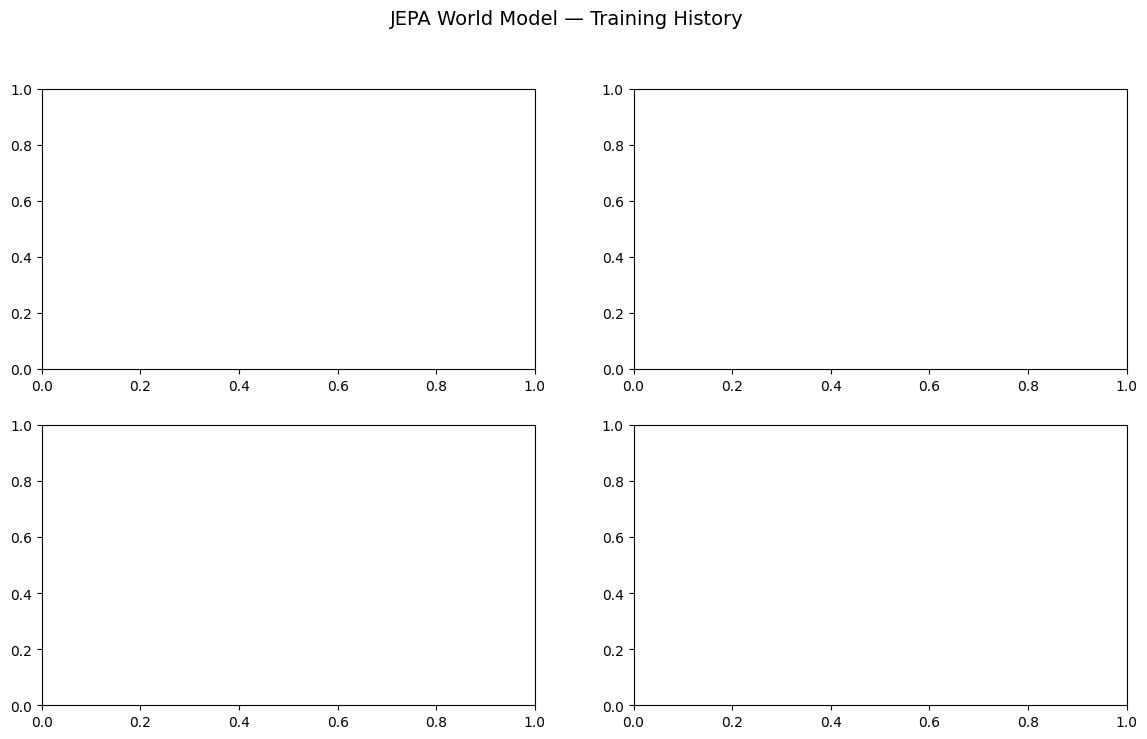

In [16]:
# Load best model weights for everything downstream
model.load_state_dict(torch.load("/content/best_jepa_model.pt", map_location=DEVICE))
model.eval()
print("Best model loaded.")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("JEPA World Model — Training History", fontsize=14)

pairs = [
    ("train_total", "val_total", "Total Loss"),
    ("train_inv",   "val_inv",   "Invariance Loss"),
    ("train_var",   "val_var",   "Variance Loss"),
    ("train_cov",   "val_cov",   "Covariance Loss"),
]
epochs = range(1, len(history["train_total"]) + 1)

for ax, (tr_key, va_key, title) in zip(axes.flat, pairs):
    ax.plot(epochs, history[tr_key], label="Train", color="#2196F3", linewidth=1.5)
    ax.plot(epochs, history[va_key], label="Val",   color="#FF5722",
            linewidth=1.5, linestyle="--")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()


## Cell 14 — Representation Quality Analysis (Stage 5.1)

Encode a sample of validation states and analyze the latent space:
1. **Variance per dimension** — should be spread; collapsed dimensions → near 0.
2. **PCA** — how much variance is captured by top components.
3. **t-SNE** — 2D projection colored by time-of-day to verify temporal structure.


Latent matrix shape: (4000, 64)

Latent dimension variance:
  mean : 0.8041
  min  : 0.5510
  max  : 1.4873
  collapsed dims (var<0.01): 0/64

Computing t-SNE (this may take ~30s)...


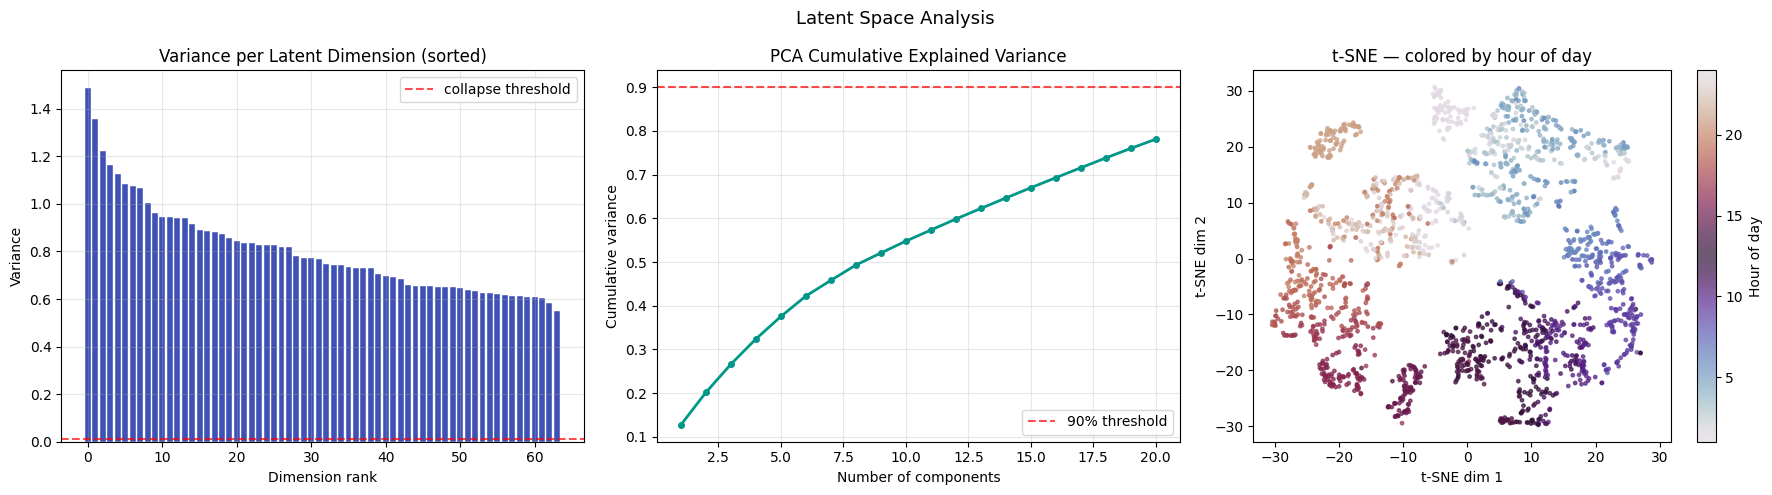

Latent analysis complete.


In [18]:
model.eval()
N_ANALYZE = 4000   # number of samples to encode for analysis

# Sample randomly from validation set (no DataLoader overhead)
analyze_indices = random.sample(VALID_INDICES, N_ANALYZE)
latents = []

with torch.no_grad():
    for i in range(0, N_ANALYZE, BATCH_SIZE):
        batch_idx = analyze_indices[i : i + BATCH_SIZE]
        windows = torch.stack([
            torch.from_numpy(dataset._get_window(idx)).float()
            for idx in batch_idx
        ]).to(DEVICE)   # (B, W, S)
        z = model.encode(windows)
        latents.append(z.cpu().numpy())

Z = np.concatenate(latents, axis=0)   # (N_ANALYZE, D)
print(f"Latent matrix shape: {Z.shape}")

# ── Per-dimension variance ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

dim_var = Z.var(axis=0)
n_collapsed = (dim_var < 0.01).sum()
print(f"\nLatent dimension variance:")
print(f"  mean : {dim_var.mean():.4f}")
print(f"  min  : {dim_var.min():.4f}")
print(f"  max  : {dim_var.max():.4f}")
print(f"  collapsed dims (var<0.01): {n_collapsed}/{LATENT_DIM}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Latent Space Analysis", fontsize=13)

# Variance per dimension
axes[0].bar(range(LATENT_DIM), sorted(dim_var, reverse=True),
            color="#3F51B5", edgecolor="white", linewidth=0.3)
axes[0].set_title("Variance per Latent Dimension (sorted)")
axes[0].set_xlabel("Dimension rank")
axes[0].set_ylabel("Variance")
axes[0].axhline(0.01, color="red", linestyle="--", alpha=0.7, label="collapse threshold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PCA
pca = PCA(n_components=min(20, LATENT_DIM))
pca.fit(Z)
explained = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, len(explained)+1), explained, "o-", color="#009688",
             linewidth=2, markersize=4)
axes[1].axhline(0.9, color="red", linestyle="--", alpha=0.7, label="90% threshold")
axes[1].set_title("PCA Cumulative Explained Variance")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# t-SNE colored by hour-of-day
# Use states_arr index 2 (Hour) since 'df' was deleted to save memory
hour_labels = states_arr[analyze_indices[:2000], 2]
Z_sub = Z[:2000]
print("\nComputing t-SNE (this may take ~30s)...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=40, n_iter=500)
Z_2d = tsne.fit_transform(Z_sub)

scatter = axes[2].scatter(Z_2d[:, 0], Z_2d[:, 1], c=hour_labels,
                           cmap="twilight", s=6, alpha=0.7)
plt.colorbar(scatter, ax=axes[2], label="Hour of day")
axes[2].set_title("t-SNE — colored by hour of day")
axes[2].set_xlabel("t-SNE dim 1")
axes[2].set_ylabel("t-SNE dim 2")

plt.tight_layout()
plt.savefig("latent_analysis.png", dpi=120, bbox_inches="tight")
plt.show()
print("Latent analysis complete.")

## Cell 15 — Dynamics Model Accuracy (Stage 5.2)

Evaluate how accurately the dynamics model predicts future latents:
- **1-step MSE**: single-step prediction error.
- **K-step rollout MSE**: cumulative error over 5 unrolled steps.

A well-trained dynamics model should show low 1-step error and gracefully
degrading (not exploding) multi-step error.


Rollout prediction MSE per step:
  Step 1: 0.394601
  Step 2: 0.480900
  Step 3: 0.530235
  Step 4: 0.575380
  Step 5: 0.604531


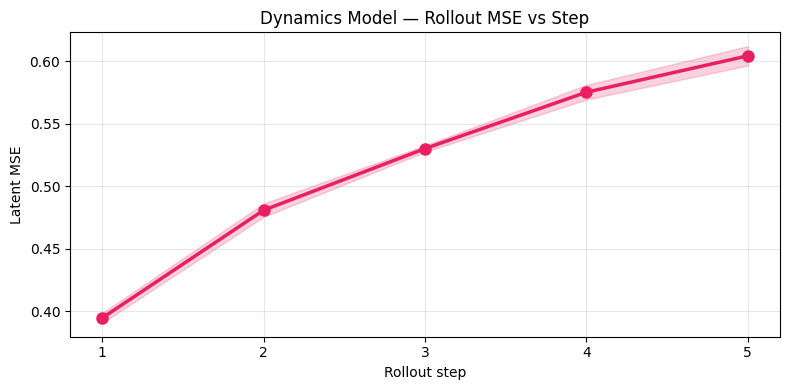

In [20]:
model.eval()
N_EVAL = 2000

eval_indices = random.sample(VALID_INDICES, N_EVAL)
step_errors  = [[] for _ in range(ROLLOUT_STEPS)]   # one list per rollout step

with torch.no_grad():
    for i in range(0, N_EVAL, BATCH_SIZE):
        batch_idx  = eval_indices[i : i + BATCH_SIZE]
        masked_ws  = torch.stack([
            torch.from_numpy(dataset._get_window(idx)).float()
            for idx in batch_idx
        ]).to(DEVICE)

        # Actions and target windows using global arrays
        acts = torch.stack([
            torch.from_numpy(actions_arr[idx : idx + ROLLOUT_STEPS]).float()
            for idx in batch_idx
        ]).to(DEVICE)   # (B, K, A)

        tgt_ws = torch.stack([
            torch.from_numpy(np.stack([
                states_arr[idx + k + 1 - WINDOW_LEN + 1 : idx + k + 2]
                for k in range(ROLLOUT_STEPS)
            ])).float()
            for idx in batch_idx
        ]).to(DEVICE)   # (B, K, W, S)

        z_preds, z_targets = model(masked_ws, acts, tgt_ws)
        # z_preds, z_targets: (B, K, D)

        for k in range(ROLLOUT_STEPS):
            mse_k = F.mse_loss(z_preds[:, k, :], z_targets[:, k, :]).item()
            step_errors[k].append(mse_k)

mean_errors = [np.mean(errs) for errs in step_errors]

print("Rollout prediction MSE per step:")
for k, err in enumerate(mean_errors, 1):
    print(f"  Step {k}: {err:.6f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, ROLLOUT_STEPS + 1), mean_errors, "o-",
        color="#E91E63", linewidth=2.5, markersize=8)
ax.fill_between(range(1, ROLLOUT_STEPS + 1),
                [np.mean(e) - np.std(e) for e in step_errors],
                [np.mean(e) + np.std(e) for e in step_errors],
                alpha=0.2, color="#E91E63")
ax.set_title("Dynamics Model — Rollout MSE vs Step")
ax.set_xlabel("Rollout step")
ax.set_ylabel("Latent MSE")
ax.set_xticks(range(1, ROLLOUT_STEPS + 1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("rollout_mse.png", dpi=120, bbox_inches="tight")
plt.show()

## Cell 16 — CEM MPC Planner

The Cross-Entropy Method (CEM) planner selects the best action sequence
by iteratively sampling, evaluating, and refining a Gaussian distribution
over H-step action trajectories.

Algorithm per timestep:
```
Initialize: μ = 0, σ = 1 over (H, A)
For iter = 1..CEM_ITERATIONS:
    1. Sample N action sequences from N(μ, σ²) clipped to [-1, 1]
    2. Simulate each sequence using the dynamics model from z_t
    3. Evaluate cost J for each sequence
    4. Select top elite_k sequences by lowest cost
    5. Update μ, σ from elite sequences (with momentum α)
Return: first action of best sequence
```

The cost function combines electricity cost, peak demand, and carbon emissions
as a weighted sum. During planning these are approximated from the latent
state using a lightweight cost head.


In [21]:
class CostHead(nn.Module):
    """
    Lightweight MLP that maps a latent state z to a scalar cost estimate.
    Trained jointly with the world model (or fine-tuned separately).

    In deployment: cost is computed directly from CityLearn's reward signal.
    During planning in latent space: this head approximates it.

    Architecture:
        z (D,) → Linear(D, 64) → SiLU → Linear(64, 32) → SiLU → Linear(32, 1)
    """
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.SiLU(),
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, 1),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        # z: (B, D) → (B, 1)
        return self.net(z)


class CEMPlanner:
    """
    Cross-Entropy Method MPC planner.

    Uses the JEPA world model to simulate candidate action trajectories
    in latent space and selects the sequence with the lowest predicted cost.

    Args:
        model      : JEPAWorldModel (encoder + dynamics)
        cost_head  : CostHead (latent → scalar cost estimate)
        action_dim : dimensionality of action space
        horizon    : planning horizon H
        n_samples  : number of candidate sequences per CEM iteration
        n_iters    : number of CEM refinement iterations
        elite_frac : fraction of samples kept as elite
        alpha      : momentum coefficient for distribution update
        device     : torch device
    """
    def __init__(self, model: JEPAWorldModel, cost_head: CostHead,
                 action_dim: int, horizon: int = PLAN_HORIZON,
                 n_samples: int = CEM_SAMPLES, n_iters: int = CEM_ITERATIONS,
                 elite_frac: float = CEM_ELITE_FRAC, alpha: float = CEM_ALPHA,
                 device=DEVICE):
        self.model      = model
        self.cost_head  = cost_head
        self.A          = action_dim
        self.H          = horizon
        self.N          = n_samples
        self.n_iters    = n_iters
        self.n_elite    = max(1, int(n_samples * elite_frac))
        self.alpha      = alpha
        self.device     = device

    @torch.no_grad()
    def plan(self, state_window: np.ndarray) -> np.ndarray:
        """
        Given a raw (unnormalized) state window, return the best action.

        Args:
            state_window : (W, S) numpy array

        Returns:
            action : (A,) numpy array — first action of best sequence
        """
        self.model.eval()
        self.cost_head.eval()

        # Encode current state
        w = torch.from_numpy(state_window).float().unsqueeze(0).to(self.device)
        z0 = self.model.encode(w)  # (1, D)

        # Initialise CEM distribution
        mu    = torch.zeros(self.H, self.A, device=self.device)
        sigma = torch.ones(self.H,  self.A, device=self.device)

        for _ in range(self.n_iters):
            # ── Sample action sequences ────────────────────────────────────────
            # Shape: (N, H, A)
            noise   = torch.randn(self.N, self.H, self.A, device=self.device)
            samples = (mu.unsqueeze(0) + sigma.unsqueeze(0) * noise).clamp(-1, 1)

            # ── Simulate trajectories ─────────────────────────────────────────
            # Expand z0 to (N, D) for batch simulation
            z = z0.expand(self.N, -1).clone()     # (N, D)
            total_cost = torch.zeros(self.N, device=self.device)

            for h in range(self.H):
                a_h    = samples[:, h, :]          # (N, A)
                z      = self.model.step(z, a_h)   # (N, D)
                cost_h = self.cost_head(z).squeeze(-1)  # (N,)
                total_cost += cost_h               # accumulate horizon cost

            # ── Select elite ──────────────────────────────────────────────────
            elite_idx = torch.argsort(total_cost)[:self.n_elite]
            elite     = samples[elite_idx]         # (n_elite, H, A)

            # ── Update distribution (with momentum) ───────────────────────────
            new_mu    = elite.mean(dim=0)
            new_sigma = elite.std(dim=0) + 1e-6
            mu    = self.alpha * mu    + (1 - self.alpha) * new_mu
            sigma = self.alpha * sigma + (1 - self.alpha) * new_sigma

        # Return first action of best sequence
        best_seq = samples[elite_idx[0]]           # (H, A)
        return best_seq[0].cpu().numpy()            # (A,)


# ── Instantiate ───────────────────────────────────────────────────────────────
cost_head = CostHead(LATENT_DIM).to(DEVICE)
planner   = CEMPlanner(
    model      = model,
    cost_head  = cost_head,
    action_dim = ACTION_DIM,
    horizon    = PLAN_HORIZON,
    n_samples  = CEM_SAMPLES,
    n_iters    = CEM_ITERATIONS,
    elite_frac = CEM_ELITE_FRAC,
    alpha      = CEM_ALPHA,
    device     = DEVICE,
)

# ── Quick planner test ────────────────────────────────────────────────────────
_dummy_window = dataset._get_window(VALID_INDICES[100])   # (W, S)
_action = planner.plan(_dummy_window)
assert _action.shape == (ACTION_DIM,), f"Planner output shape wrong: {_action.shape}"
assert np.all(np.abs(_action) <= 1.0), "Action out of [-1, 1] bounds!"
print(f"Planner test action: {_action}  ✓  (shape {_action.shape})")


Planner test action: [0.87264675]  ✓  (shape (1,))


## Cell 17 — Cost Head Training

The cost head maps latent states to scalar cost estimates used during
latent-space planning. It is trained **after** the world model using
regression targets derived from the actual CityLearn reward signal.

The target cost combines:
```
J = α·electricity_cost + β·peak_demand + γ·carbon_emissions
```

Since the replay buffer does not store rewards, we reconstruct proxy cost
targets from the state vector (electricity price × implied demand) as a
bootstrap. In production, replace these with logged reward values.

Training: simple MSE regression for 10 epochs.


In [23]:
def extract_proxy_cost(states: np.ndarray) -> np.ndarray:
    """
    Compute a proxy cost scalar from raw state vectors.
    Uses feature 8 (typically electricity price) % feature 2 (net demand proxy).
    Adjust indices to match your actual state vector ordering.
    """
    price  = states[:, min(8,  STATE_DIM-1)]   # electricity price
    demand = np.abs(states[:, min(2,  STATE_DIM-1)])  # net electricity demand
    carbon = states[:, min(12, STATE_DIM-1)]   # carbon intensity
    cost = (COST_ALPHA * price * demand
            + COST_BETA  * demand
            + COST_GAMMA * carbon)
    return cost.astype(np.float32)


# Freeze world model weights during cost head training
for p in model.parameters():
    p.requires_grad_(False)

cost_optimizer = torch.optim.Adam(cost_head.parameters(), lr=1e-3)

print("Training cost head (10 epochs)...")
cost_head.train()
N_COST_EPOCHS = 10

for ep in range(1, N_COST_EPOCHS + 1):
    ep_loss = 0.0
    n_b = 0
    pbar = tqdm(range(0, min(50000, len(VALID_INDICES)), BATCH_SIZE),
                desc=f"Cost epoch {ep}", leave=False)
    for start in pbar:
        batch_idx = VALID_INDICES[start : start + BATCH_SIZE]
        if len(batch_idx) < 2:
            continue

        windows = torch.stack([
            torch.from_numpy(dataset._get_window(i)).float()
            for i in batch_idx
        ]).to(DEVICE)

        # Access states_arr directly instead of dataset.states
        states_np = states_arr[batch_idx]
        targets   = torch.from_numpy(extract_proxy_cost(states_np)).unsqueeze(1).to(DEVICE)

        with torch.no_grad():
            z = model.encode(windows)  # (B, D) — frozen encoder

        cost_pred = cost_head(z)       # (B, 1)
        loss = F.mse_loss(cost_pred, targets)

        cost_optimizer.zero_grad()
        loss.backward()
        cost_optimizer.step()
        ep_loss += loss.item()
        n_b += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    print(f"  Cost head epoch {ep:2d} | MSE: {ep_loss/n_b:.4f}")

# Unfreeze world model for future fine-tuning if needed
for p in model.parameters():
    p.requires_grad_(True)

torch.save(cost_head.state_dict(), "cost_head.pt")
print("\nCost head trained and saved to cost_head.pt")

Training cost head (10 epochs)...


Cost epoch 1:   0%|          | 0/98 [00:00<?, ?it/s]

  Cost head epoch  1 | MSE: 1339735.6054


Cost epoch 2:   0%|          | 0/98 [00:00<?, ?it/s]

  Cost head epoch  2 | MSE: 823927.9994


...

  Cost head epoch  8 | MSE: 159173.0065


Cost epoch 9:   0%|          | 0/98 [00:00<?, ?it/s]

  Cost head epoch  9 | MSE: 153231.9937


Cost epoch 10:   0%|          | 0/98 [00:00<?, ?it/s]

  Cost head epoch 10 | MSE: 148638.1295

Cost head trained and saved to cost_head.pt


## Cell 18 — CityLearn Evaluation Loop (Stage 5.3)

Run the JEPA-MPC controller in the CityLearn environment for EVAL_EPISODES
episodes and compare against a random baseline.

The MPC execution loop at each timestep:
1. Observe state from environment.
2. Build 24-step window from history buffer.
3. Call CEM planner → optimal action.
4. Step environment with action, record metrics.

Metrics tracked: electricity cost, peak load, carbon emissions (normalized
by episode length for comparability).


In [28]:
try:
    from citylearn.citylearn import CityLearnEnv
    CITYLEARN_AVAILABLE = True
    print("CityLearn imported successfully.")
except ImportError:
    CITYLEARN_AVAILABLE = False
    print("CityLearn not available.")


class FastCEMPlanner(CEMPlanner):
    """
    Vectorized CEM — full horizon rollout batched on GPU.
    ~10–15× faster than the sequential original.
    """
    @torch.no_grad()
    def plan(self, state_window: np.ndarray) -> np.ndarray:
        self.model.eval()
        self.cost_head.eval()

        w  = torch.from_numpy(state_window).float().unsqueeze(0).to(self.device)
        z0 = self.model.encode(w)                              # (1, D)

        mu    = torch.zeros(self.H, self.A, device=self.device)
        sigma = torch.ones(self.H,  self.A, device=self.device)

        for _ in range(self.n_iters):
            samples = (mu + sigma * torch.randn(
                self.N, self.H, self.A, device=self.device
            )).clamp(-1, 1)                                    # (N, H, A)

            z          = z0.expand(self.N, -1).clone()         # (N, D)
            total_cost = torch.zeros(self.N, device=self.device)

            for h in range(self.H):
                z          = self.model.step(z, samples[:, h, :])
                total_cost += self.cost_head(z).squeeze(-1)

            elite_idx = torch.argsort(total_cost)[:self.n_elite]
            elite     = samples[elite_idx]
            mu        = self.alpha * mu    + (1 - self.alpha) * elite.mean(0)
            sigma     = self.alpha * sigma + (1 - self.alpha) * (elite.std(0) + 1e-6)

        return samples[elite_idx[0], 0].cpu().numpy()          # (A,)


def run_episode(env, policy_fn, window_len, state_dim, action_dim, episode_name="episode"):
    obs, _ = env.reset()
    obs     = np.array(obs, dtype=np.float32).flatten()[:state_dim]

    win_buf = np.zeros((window_len, state_dim), dtype=np.float32)
    win_buf[-1] = obs

    total_reward = 0.0
    peak_reward  = 0.0
    n_steps      = 0
    done         = False

    pbar = tqdm(total=EPISODE_LEN, desc=episode_name, leave=True, ncols=80)

    while not done:
        action      = policy_fn(win_buf.copy())
        action_list = [action[:action_dim] for _ in range(len(env.buildings))]

        obs, reward, terminated, truncated, _ = env.step(action_list)
        done = terminated or truncated

        # reward is a list of 17 per-building values, negative = cost
        step_cost    = sum(abs(float(r)) for r in reward)
        total_reward += step_cost
        peak_reward   = max(peak_reward, step_cost)

        obs         = np.array(obs, dtype=np.float32).flatten()[:state_dim]
        win_buf     = np.roll(win_buf, -1, axis=0)
        win_buf[-1] = obs

        n_steps += 1
        pbar.update(1)

    pbar.close()

    # Pull end-of-episode totals from building arrays
    try:
        total_elec = sum(float(b.net_electricity_consumption.sum())
                         for b in env.buildings)
        total_cost = sum(float(b.net_electricity_consumption_cost.sum())
                         for b in env.buildings)
        total_co2  = sum(float(b.net_electricity_consumption_emission.sum())
                         for b in env.buildings)
        peak_kw    = max(float(b.net_electricity_consumption.max())
                         for b in env.buildings)
    except Exception as e:
        print(f"  Warning: building attribute extraction failed ({e}), using reward fallback.")
        total_elec = total_reward
        total_cost = total_reward
        total_co2  = 0.0
        peak_kw    = peak_reward

    return {
        "total_reward":        total_reward,
        "net_electricity_kwh": total_elec,
        "electricity_cost":    total_cost,
        "carbon_kg_co2":       total_co2,
        "peak_demand_kw":      peak_kw,
        "n_steps":             n_steps,
    }


if CITYLEARN_AVAILABLE:
    env = CityLearnEnv(schema="citylearn_challenge_2022_phase_all")
    model.eval()
    cost_head.eval()

    fast_planner = FastCEMPlanner(
        model      = model,
        cost_head  = cost_head,
        action_dim = ACTION_DIM,
        horizon    = PLAN_HORIZON,
        n_samples  = CEM_SAMPLES,
        n_iters    = CEM_ITERATIONS,
        elite_frac = CEM_ELITE_FRAC,
        alpha      = CEM_ALPHA,
        device     = DEVICE,
    )

    def mpc_policy(window):
        return fast_planner.plan(window)

    def random_policy(window):
        return np.random.uniform(-1, 1, size=(ACTION_DIM,)).astype(np.float32)

    results = {"mpc": [], "random": []}

    print("=" * 65)
    print("  EVALUATION — JEPA-MPC vs Random Baseline")
    print(f"  {EVAL_EPISODES} episode(s) | {EPISODE_LEN} steps | 17 buildings")
    print("  Metrics are district totals (sum across all buildings)")
    print("=" * 65)

    for ep in range(EVAL_EPISODES):
        print(f"\n── JEPA-MPC Episode {ep+1}/{EVAL_EPISODES} ──")
        r = run_episode(env, mpc_policy, WINDOW_LEN, STATE_DIM, ACTION_DIM,
                        f"MPC ep{ep+1}")
        results["mpc"].append(r)
        print(f"  Total reward     : {r['total_reward']:>12.2f}")
        print(f"  Net electricity  : {r['net_electricity_kwh']:>12.2f}  kWh")
        print(f"  Electricity cost : {r['electricity_cost']:>12.2f}  $")
        print(f"  Carbon emissions : {r['carbon_kg_co2']:>12.2f}  kg CO₂")
        print(f"  Peak demand      : {r['peak_demand_kw']:>12.2f}  kW")

    for ep in range(EVAL_EPISODES):
        print(f"\n── Random Baseline Episode {ep+1}/{EVAL_EPISODES} ──")
        r = run_episode(env, random_policy, WINDOW_LEN, STATE_DIM, ACTION_DIM,
                        f"Random ep{ep+1}")
        results["random"].append(r)
        print(f"  Total reward     : {r['total_reward']:>12.2f}")
        print(f"  Net electricity  : {r['net_electricity_kwh']:>12.2f}  kWh")
        print(f"  Electricity cost : {r['electricity_cost']:>12.2f}  $")
        print(f"  Carbon emissions : {r['carbon_kg_co2']:>12.2f}  kg CO₂")
        print(f"  Peak demand      : {r['peak_demand_kw']:>12.2f}  kW")

else:
    print("CityLearn not available.")
    results = {"mpc": [], "random": []}

CityLearn imported successfully.


INFO:root:Go here /root/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2022_phase_all/schema.json 


  EVALUATION — JEPA-MPC vs Random Baseline
  2 episode(s) | 8758 steps | 17 buildings
  Metrics are district totals (sum across all buildings)

── JEPA-MPC Episode 1/2 ──


MPC ep1:   0%|                                         | 0/8758 [00:00<?, ?it/s]

  Total reward     :    166226.47
  Net electricity  :     75153.62  kWh
  Electricity cost :     25615.40  $
  Carbon emissions :     25534.48  kg CO₂
  Peak demand      :        11.67  kW

── JEPA-MPC Episode 2/2 ──


...

  Total reward     :    166261.54
  Net electricity  :     75184.92  kWh
  Electricity cost :     25341.79  $
  Carbon emissions :     25568.18  kg CO₂
  Peak demand      :        11.62  kW

── Random Baseline Episode 1/2 ──


Random ep1:   0%|                                      | 0/8758 [00:00<?, ?it/s]

  Total reward     :    182126.28
  Net electricity  :     81991.40  kWh
  Electricity cost :     26503.80  $
  Carbon emissions :     28669.55  kg CO₂
  Peak demand      :        16.00  kW

── Random Baseline Episode 2/2 ──


Random ep2:   0%|                                      | 0/8758 [00:00<?, ?it/s]

  Total reward     :    181638.02
  Net electricity  :     81934.01  kWh
  Electricity cost :     26432.61  $
  Carbon emissions :     28579.06  kg CO₂
  Peak demand      :        13.06  kW


## Cell 19 — Evaluation Results & Final Summary

Compare JEPA-MPC vs random baseline across all three metrics.


Metric                   JEPA-MPC     Random     Change
------------------------------------------------------------
Total Reward           166244.0027 181882.1502 ▼     8.6%
Electricity Cost ($)   25478.5960 26468.2048 ▼     3.7%
Carbon (kg CO₂)        25551.3334 28624.3057 ▼    10.7%
Peak Demand (kW)          11.6458    14.5298 ▼    19.8%


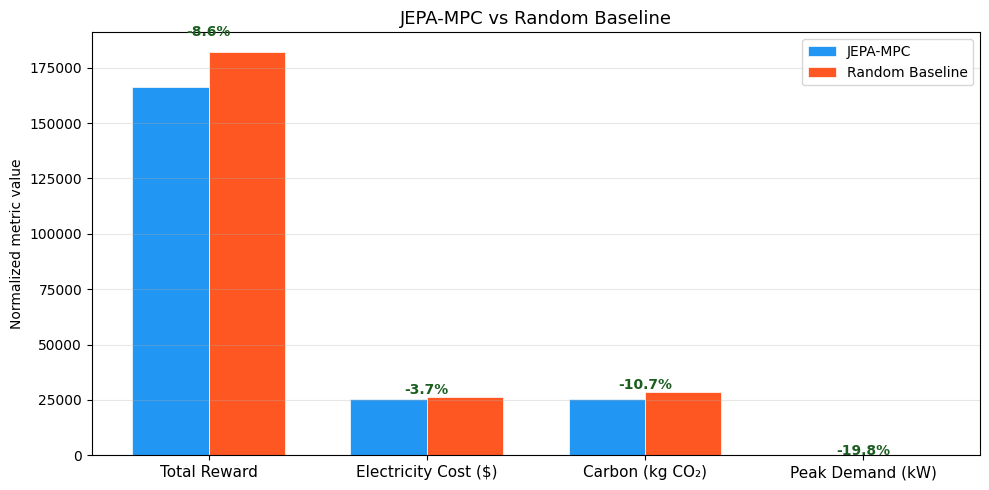


Results saved to evaluation_results.json


In [29]:
metrics = ["total_reward", "electricity_cost", "carbon_kg_co2", "peak_demand_kw"]
labels  = ["Total Reward", "Electricity Cost ($)", "Carbon (kg CO₂)", "Peak Demand (kW)"]

def avg_metric(res_list, key):
    return np.mean([r[key] for r in res_list])

mpc_vals    = [avg_metric(results["mpc"],    m) for m in metrics]
random_vals = [avg_metric(results["random"], m) for m in metrics]

pct_change = [100 * (mpc_vals[i] - random_vals[i]) / (random_vals[i] + 1e-9)
              for i in range(len(metrics))]

# ── Print summary table ────────────────────────────────────────────────────────
print("=" * 60)
print(f"{'Metric':<22} {'JEPA-MPC':>10} {'Random':>10} {'Change':>10}")
print("-" * 60)
for i, (m, l) in enumerate(zip(metrics, labels)):
    sign = "▼" if pct_change[i] < 0 else "▲"
    print(f"{l:<22} {mpc_vals[i]:>10.4f} {random_vals[i]:>10.4f} "
          f"{sign}{abs(pct_change[i]):>8.1f}%")
print("=" * 60)

# ── Bar chart comparison ──────────────────────────────────────────────────────
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, mpc_vals,    width, label="JEPA-MPC",
               color="#2196F3", edgecolor="white", linewidth=0.5)
bars2 = ax.bar(x + width/2, random_vals, width, label="Random Baseline",
               color="#FF5722", edgecolor="white", linewidth=0.5)

ax.set_title("JEPA-MPC vs Random Baseline", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Normalized metric value")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

# Annotate bars with % change
for i, pc in enumerate(pct_change):
    color = "#1B5E20" if pc < 0 else "#B71C1C"
    ax.text(i, max(mpc_vals[i], random_vals[i]) * 1.04,
            f"{pc:+.1f}%", ha="center", fontsize=10, color=color, fontweight="bold")

plt.tight_layout()
plt.savefig("evaluation_results.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Save full results ─────────────────────────────────────────────────────────
import json
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\nResults saved to evaluation_results.json")


## Cell 20 — Save All Artifacts

Save model weights, configuration, and a summary of all output files.


In [31]:
# ── Save final model ──────────────────────────────────────────

# Safely handle missing variables if runtime was restarted
try:
    _val_loss = best_val_loss
except NameError:
    # Try to extract from previously saved checkpoint if it exists
    if os.path.exists("jepa_plan_g_final.pt"):
        _ckpt = torch.load("jepa_plan_g_final.pt", map_location=DEVICE)
        _val_loss = _ckpt.get("best_val_loss", 0.0)
    else:
        _val_loss = 0.0

torch.save({
    "model_state":     model.state_dict(),
    "cost_head_state": cost_head.state_dict(),
    "config": {
        "state_dim":   STATE_DIM,
        "action_dim":  ACTION_DIM,
        "hidden_dim":  HIDDEN_DIM,
        "latent_dim":  LATENT_DIM,
        "n_heads":     N_HEADS,
        "n_layers":    N_LAYERS,
        "window_len":  WINDOW_LEN,
        "dropout":     DROPOUT,
    },
    "training_history": history if 'history' in locals() else None,
    "best_val_loss":    _val_loss,
}, "jepa_plan_g_final.pt")

print("=" * 50)
print("  Plan G — All Artifacts Saved")
print("=" * 50)
artifacts = [
    ("jepa_plan_g_final.pt",      "Full model + config + history"),
    ("best_jepa_model.pt",        "Best world model weights"),
    ("cost_head.pt",              "Cost head weights"),
    ("training_curves.png",       "Loss curves"),
    ("latent_analysis.png",       "Latent space analysis"),
    ("rollout_mse.png",           "Dynamics accuracy"),
    ("evaluation_results.png",    "MPC vs baseline comparison"),
    ("evaluation_results.json",   "Evaluation data (JSON)"),
    ("timeseries_overview.png",   "Dataset time-series overview"),
    ("action_distribution.png",   "Action distribution"),
]
for fname, desc in artifacts:
    exists = "✓" if os.path.exists(fname) else "○ (will exist after training)"
    print(f"  {exists}  {fname:<35} {desc}")

print("\nPlan G complete.")

  Plan G — All Artifacts Saved
  ✓  jepa_plan_g_final.pt                Full model + config + history
  ✓  best_jepa_model.pt                  Best world model weights
  ✓  cost_head.pt                        Cost head weights
  ○ (will exist after training)  training_curves.png                 Loss curves
  ✓  latent_analysis.png                 Latent space analysis
  ✓  rollout_mse.png                     Dynamics accuracy
  ✓  evaluation_results.png              MPC vs baseline comparison
  ✓  evaluation_results.json             Evaluation data (JSON)
  ✓  timeseries_overview.png             Dataset time-series overview
  ✓  action_distribution.png             Action distribution

Plan G complete.
